# Caricamento dataset e analisi esplorativa

In [1]:
import pandas as pd

df = pd.read_csv("obesity.csv")

df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
# Abbiamo etichetta categorica e anche varie features categoriche, controlliamo se mancano dati

print(df.isna().mean() * 100) # nessun dato mancancante, non e' necessario effetuare imputazione

X = df.drop(columns="NObeyesdad")
y = df["NObeyesdad"]

Gender                            0.0
Age                               0.0
Height                            0.0
Weight                            0.0
family_history_with_overweight    0.0
FAVC                              0.0
FCVC                              0.0
NCP                               0.0
CAEC                              0.0
SMOKE                             0.0
CH2O                              0.0
SCC                               0.0
FAF                               0.0
TUE                               0.0
CALC                              0.0
MTRANS                            0.0
NObeyesdad                        0.0
dtype: float64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train,X_test,y_train,y_test = train_test_split(X,y_encoded,stratify=y_encoded, random_state=42, test_size=0.15)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = X_train.select_dtypes(include=["number"]).columns
cat_features = X_train.select_dtypes(include=["bool", "string", "object"]).columns

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),    
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)



In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print(pd.Series(y_encoded).nunique()) # Riduciamo a 6 componenti

lda = LinearDiscriminantAnalysis(n_components=6)
lda.set_output(transform="pandas")

X_train_final = lda.fit_transform(X_train_processed, y_train)
X_test_final = lda.transform(X_test_processed)


X_train_final.head()

7


,lineardiscriminantanalysis0,lineardiscriminantanalysis1,lineardiscriminantanalysis2,lineardiscriminantanalysis3,lineardiscriminantanalysis4,lineardiscriminantanalysis5
1994,-8.578527,-2.002448,0.210555,0.005419,-0.072947,0.404837
17,-0.930445,0.836935,-0.854716,0.722486,-1.557138,2.236574
206,-0.935860,0.830215,2.178449,0.213354,-1.423595,2.359069
1944,-8.625892,-1.735466,0.711398,0.322774,0.055747,0.276574
1198,0.696299,-0.509228,0.108095,0.182193,0.773292,-0.053418


In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'] 
}

cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
rfc = RandomForestClassifier(random_state=42)
grid = GridSearchCV(estimator=rfc, param_grid=grid_params, scoring='accuracy', cv=cv)

grid.fit(X_train_final, y_train)




,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [6]:
best_model = grid.best_estimator_
best_score = grid.best_score_
best_params = grid.best_params_

test_acc = best_model.score(X_test_final, y_test)

print(f"Miglior modello : {best_model}")
print(f"Migliori iperparametri: {best_params}")
print(f"Miglior punteggio: {best_score}")

print(f"Test accuracy : {test_acc}")

Miglior modello : RandomForestClassifier(criterion='entropy', random_state=42)
Migliori iperparametri: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Miglior punteggio: 0.9453649958761924
Test accuracy : 0.9369085173501577


# rete neurale

In [7]:
import torch
import numpy as np
import torchnn as tnn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(X_train_final, y_train, stratify=y_train, random_state=42, test_size=0.15)
# tensore = (batch_size, canali, lunghezza)

class Data(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(np.array(y), dtype=torch.long)
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    def __len__(self):
        return len(self.X)

train_data = Data(X_train_nn, y_train_nn)
val_data = Data(X_val_nn, y_val_nn)
test_data = Data(X_test_final, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

from torch import nn
from torch.functional import F  

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32,64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.AdaptiveAvgPool1d(1) # si andra' a moltiplicare con i canali in uscita
        self.fc1 = nn.Linear(64,128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128,7)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x) # x.shape al momento (64,64,1)
        x = torch.flatten(x, start_dim=1)  # x.shape dopo flatten(64,64)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
    print("modello caricato!")




modello caricato!


# Addestramento modello


Epoch    1: 100%|██████████| 24/24 [00:00<00:00, 296.22it/s]


Train loss: 1.6368
Validation loss: 1.3775
Test loss: 1.4301 Accuracy:   0.51
Metrics:



Epoch    2: 100%|██████████| 24/24 [00:00<00:00, 200.00it/s]


Train loss: 1.1539
Validation loss: 0.9297
Test loss: 0.9814 Accuracy:   0.71
Metrics:



Epoch    3: 100%|██████████| 24/24 [00:00<00:00, 230.77it/s]


Train loss: 0.8012
Validation loss: 0.6431
Test loss: 0.6812 Accuracy:   0.76
Metrics:



Epoch    4: 100%|██████████| 24/24 [00:00<00:00, 247.42it/s]


Train loss: 0.6126
Validation loss: 0.4985
Test loss: 0.5328 Accuracy:   0.82
Metrics:



Epoch    5: 100%|██████████| 24/24 [00:00<00:00, 252.64it/s]


Train loss: 0.4951
Validation loss: 0.4153
Test loss: 0.4599 Accuracy:   0.84
Metrics:



Epoch    6: 100%|██████████| 24/24 [00:00<00:00, 244.90it/s]


Train loss: 0.4300
Validation loss: 0.3516
Test loss: 0.3834 Accuracy:   0.87
Metrics:



Epoch    7: 100%|██████████| 24/24 [00:00<00:00, 235.30it/s]


Train loss: 0.3736
Validation loss: 0.3175
Test loss: 0.3368 Accuracy:   0.90
Metrics:



Epoch    8: 100%|██████████| 24/24 [00:00<00:00, 250.00it/s]


Train loss: 0.3419
Validation loss: 0.2873
Test loss: 0.2954 Accuracy:   0.90
Metrics:



Epoch    9: 100%|██████████| 24/24 [00:00<00:00, 249.99it/s]


Train loss: 0.3130
Validation loss: 0.2827
Test loss: 0.3081 Accuracy:   0.90
Metrics:



Epoch   10: 100%|██████████| 24/24 [00:00<00:00, 224.30it/s]


Train loss: 0.3039
Validation loss: 0.3031
Test loss: 0.3096 Accuracy:   0.88
Metrics:



Epoch   11: 100%|██████████| 24/24 [00:00<00:00, 242.43it/s]


Train loss: 0.2809
Validation loss: 0.2422
Test loss: 0.2903 Accuracy:   0.89
Metrics:



Epoch   12: 100%|██████████| 24/24 [00:00<00:00, 237.62it/s]


Train loss: 0.2670
Validation loss: 0.2423
Test loss: 0.2361 Accuracy:   0.92
Metrics:



Epoch   13: 100%|██████████| 24/24 [00:00<00:00, 218.18it/s]


Train loss: 0.2663
Validation loss: 0.2369
Test loss: 0.2692 Accuracy:   0.89
Metrics:



Epoch   14: 100%|██████████| 24/24 [00:00<00:00, 258.07it/s]


Train loss: 0.2420
Validation loss: 0.2708
Test loss: 0.2566 Accuracy:   0.89
Metrics:



Epoch   15: 100%|██████████| 24/24 [00:00<00:00, 222.22it/s]


Train loss: 0.2606
Validation loss: 0.2358
Test loss: 0.2443 Accuracy:   0.89
Metrics:



Epoch   16: 100%|██████████| 24/24 [00:00<00:00, 226.42it/s]


Train loss: 0.2211
Validation loss: 0.2157
Test loss: 0.2151 Accuracy:   0.91
Metrics:



Epoch   17: 100%|██████████| 24/24 [00:00<00:00, 250.00it/s]


Train loss: 0.2227
Validation loss: 0.2302
Test loss: 0.2627 Accuracy:   0.88
Metrics:



Epoch   18: 100%|██████████| 24/24 [00:00<00:00, 307.70it/s]


Train loss: 0.2475
Validation loss: 0.2086
Test loss: 0.2300 Accuracy:   0.91
Metrics:



Epoch   19: 100%|██████████| 24/24 [00:00<00:00, 237.62it/s]


Train loss: 0.1917
Validation loss: 0.2010
Test loss: 0.2478 Accuracy:   0.89
Metrics:



Epoch   20: 100%|██████████| 24/24 [00:00<00:00, 235.29it/s]


Train loss: 0.2234
Validation loss: 0.2044
Test loss: 0.2259 Accuracy:   0.91
Metrics:



Epoch   21: 100%|██████████| 24/24 [00:00<00:00, 228.57it/s]


Train loss: 0.1983
Validation loss: 0.2128
Test loss: 0.2285 Accuracy:   0.91
Metrics:



Epoch   22: 100%|██████████| 24/24 [00:00<00:00, 252.63it/s]


Train loss: 0.2133
Validation loss: 0.1990
Test loss: 0.2112 Accuracy:   0.93
Metrics:



Epoch   23: 100%|██████████| 24/24 [00:00<00:00, 252.63it/s]


Train loss: 0.1832
Validation loss: 0.2074
Test loss: 0.2156 Accuracy:   0.93
Metrics:



Epoch   24: 100%|██████████| 24/24 [00:00<00:00, 237.62it/s]


Train loss: 0.2087
Validation loss: 0.2115
Test loss: 0.2257 Accuracy:   0.92
Metrics:



Epoch   25: 100%|██████████| 24/24 [00:00<00:00, 250.01it/s]


Train loss: 0.2254
Validation loss: 0.2085
Test loss: 0.2142 Accuracy:   0.92
Metrics:



Epoch   26: 100%|██████████| 24/24 [00:00<00:00, 252.62it/s]


Train loss: 0.1844
Validation loss: 0.2254
Test loss: 0.2642 Accuracy:   0.89
Metrics:



Epoch   27: 100%|██████████| 24/24 [00:00<00:00, 315.79it/s]


Train loss: 0.1783
Validation loss: 0.1857
Test loss: 0.2482 Accuracy:   0.90
Metrics:



Epoch   28: 100%|██████████| 24/24 [00:00<00:00, 263.73it/s]


Train loss: 0.1626
Validation loss: 0.2113
Test loss: 0.2173 Accuracy:   0.91
Metrics:



Epoch   29: 100%|██████████| 24/24 [00:00<00:00, 250.00it/s]


Train loss: 0.1718
Validation loss: 0.2063
Test loss: 0.2421 Accuracy:   0.91
Metrics:



Epoch   30: 100%|██████████| 24/24 [00:00<00:00, 226.40it/s]


Train loss: 0.1771
Validation loss: 0.2090
Test loss: 0.1950 Accuracy:   0.91
Metrics:



Epoch   31: 100%|██████████| 24/24 [00:00<00:00, 237.62it/s]


Train loss: 0.1593
Validation loss: 0.2294
Test loss: 0.2490 Accuracy:   0.91
Metrics:



Epoch   32: 100%|██████████| 24/24 [00:00<00:00, 250.00it/s]


Train loss: 0.1766
Validation loss: 0.1844
Test loss: 0.2322 Accuracy:   0.91
Metrics:



Epoch   33: 100%|██████████| 24/24 [00:00<00:00, 247.42it/s]


Train loss: 0.1580
Validation loss: 0.2368
Test loss: 0.2487 Accuracy:   0.91
Metrics:



Epoch   34: 100%|██████████| 24/24 [00:00<00:00, 255.33it/s]


Train loss: 0.2014
Validation loss: 0.2102
Test loss: 0.2352 Accuracy:   0.90
Metrics:



Epoch   35: 100%|██████████| 24/24 [00:00<00:00, 249.99it/s]


Train loss: 0.1579
Validation loss: 0.1885
Test loss: 0.1928 Accuracy:   0.92
Metrics:



Epoch   36: 100%|██████████| 24/24 [00:00<00:00, 260.96it/s]


Train loss: 0.1562
Validation loss: 0.1996
Test loss: 0.2159 Accuracy:   0.92
Metrics:



Epoch   37: 100%|██████████| 24/24 [00:00<00:00, 247.42it/s]


Train loss: 0.1759
Validation loss: 0.1918
Test loss: 0.2104 Accuracy:   0.93
Metrics:



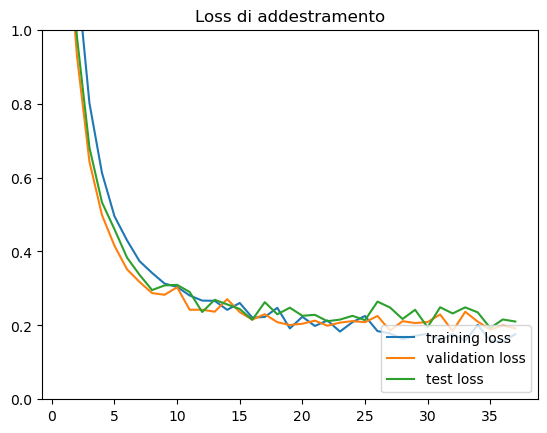

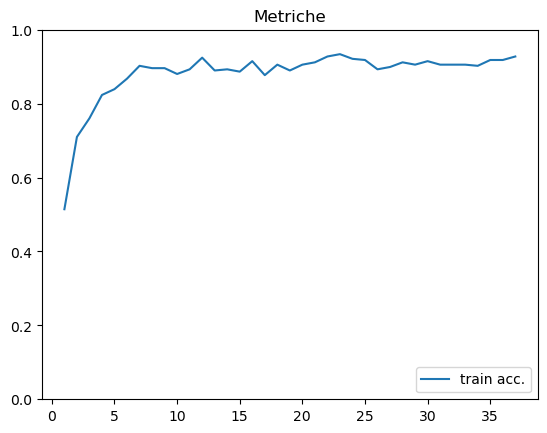

In [11]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Net().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
early_stopping = tnn.EarlyStopping(patience=5, min_delta=0.001)
loss_fn = nn.CrossEntropyLoss()

train_loss, validation_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    val_dataloader=val_loader,
    epochs=50,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    early_stopping=early_stopping,
    device=device,
    average='micro',
    metrics=[]
)

tnn.displayLosses(train_loss, test_loss, validation_loss)
tnn.displayMetrics(accuracy, test_metrics)

tnn.save_model(
    model,
    optimizer,
    len(train_loss), 
    train_loss,
    validation_loss, 
    test_loss, 
    accuracy, 
    test_metrics, 
    "best_conv1d.pt")


# Metriche e Matrice di confusione


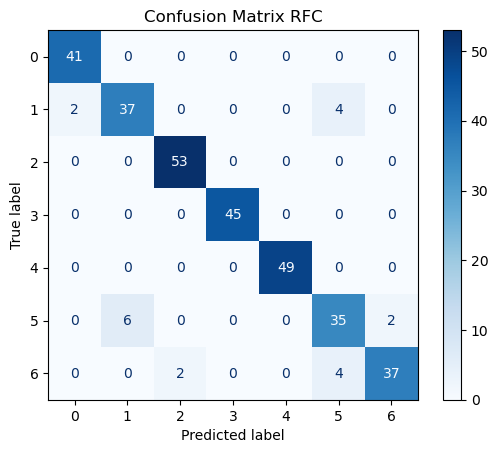

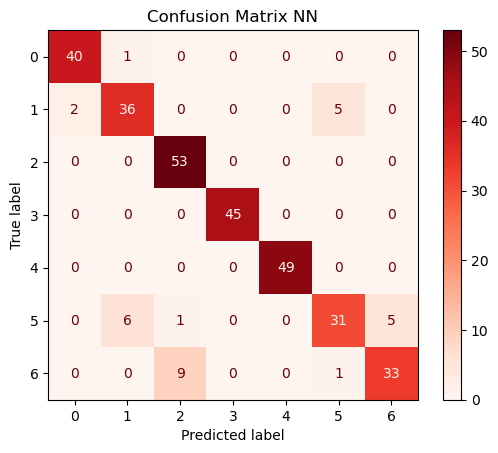

c:\Users\1234r\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\1234r\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


Auc Macro RFC: 0.9944270492289984
Auc Micro RFC: 0.9969018167825997
Auc Macro NN: 0.9929395303497995
Auc Micro NN: 0.9949380860923418


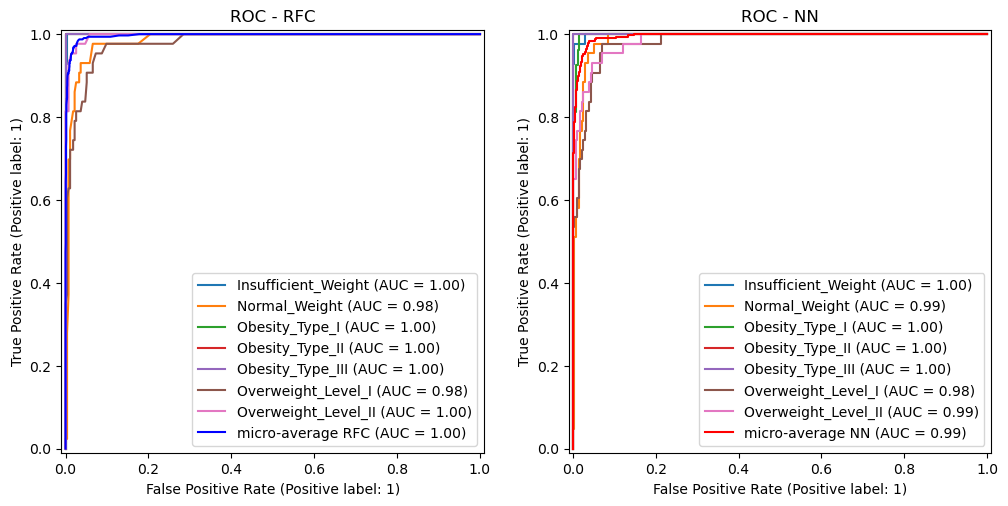

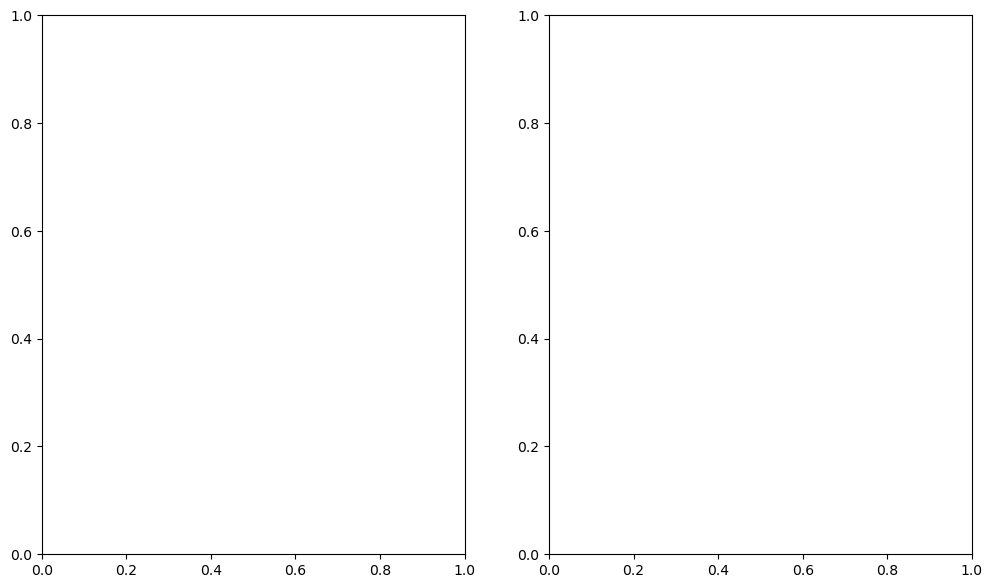

In [ ]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

def valuate(model, test_loader, device, loss_fn):
    model.eval()
    nn_true, nn_pred, nn_prob, losses = [],[],[], []

    # Disabilitiamo il calcolo del gradiente per migliore efficienza

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            losses.append(loss_fn(logits, y_batch).item())

            """dim=1 perche' senza dim softmax tratta l'intero tensore (batch, 7) come se fosse un unico vettore 
            appiattito, e restituisce un solo indice scalare.
            
            Perché ti serve lo stesso criterio in entrambi i casi, ed è il punto da fissarti in testa: 
            ogni volta che un'operazione di PyTorch collassa un tensore lungo un asse (somma, media, max, argmax, softmax...), 
            e tu hai più dimensioni, devi sempre dire esplicitamente su quale asse operare, 
            altrimenti PyTorch assume "su tutto", che quasi mai è quello che vuoi quando lavori con batch di dati. 
            Con logits/prob shape (batch, n_classi), dim=1 è quasi sempre la risposta giusta in questo tipo 
            di codice, perché è l'asse delle classi, non del batch.

            """

            # I tensori che stiamo manipolando hanno forma (batch, 7) e la funzione deve agire sulla dimensione 1 
            # ovvero le classi di classificazione che vogliamo
            
            prob = torch.softmax(logits, dim=1)
            pred = torch.argmax(prob, dim=1)

            nn_true.extend(y_batch.cpu().numpy())
            nn_pred.extend(pred.cpu().numpy())
            nn_prob.extend(prob.cpu().numpy())

    nn_true = np.array(nn_true)
    nn_pred = np.array(nn_pred)
    nn_prob = np.array(nn_prob)

    return nn_true, nn_pred, nn_prob, losses

best_model, optimizer, checkpoint = tnn.load_model("best_conv1d.pt", model, optimizer, device)


nn_true, nn_pred, nn_prob, losses = valuate(best_model, test_loader, device, loss_fn)

# plotting matrici di confusioni 

# Matrice di confusione RandomForestClassifier

rfc_pred = grid.predict(X_test_final)


cm1 = ConfusionMatrixDisplay.from_predictions(y_test, rfc_pred, cmap='Blues',)
plt.title("Confusion Matrix RFC")
plt.show()

cm2 = ConfusionMatrixDisplay.from_predictions(nn_true, nn_pred, cmap='Reds',)
plt.title("Confusion Matrix NN")
plt.show()

rfc_prob = grid.predict_proba(X_test_final)

# Dobbiamo calcolare Auc e Roc, ma bisogna tenere conto che questa e' classificazione MULTICLASSE e non binaria
# Dobbiamo fare un LabelBinarizer fissando y_test_gb

n_classes=7
lb = LabelBinarizer().fit(y_train)
y_test_rfc_bin = lb.transform(y_test)
nn_true_bin = lb.transform(nn_true) 

class_names = le.classes_

fig,ax = plt.subplots(1,2, figsize=(12,7))

for i,classes in enumerate(class_names):
    # Per ciascuna classe stampiamo AuC
    RocCurveDisplay.from_predictions(y_test_rfc_bin[:,i], rfc_prob[:,i], name=classes, ax=ax[0])
    ax[0].set_title("ROC - RFC")
    
   

for i,classes in enumerate(class_names):
    # Per ciascuna classe stampiamo AuC
    RocCurveDisplay.from_predictions(nn_true_bin[:,i], nn_prob[:,i], name=classes, ax=ax[1])
    ax[1].set_title("ROC - NN")

# Curve Micro Average Aggregate
RocCurveDisplay.from_predictions(y_test_rfc_bin.ravel(),rfc_prob.ravel(),name="micro-average RFC", color="blue", ax=ax[0])
RocCurveDisplay.from_predictions(nn_true_bin.ravel(),nn_prob.ravel(),name="micro-average NN", color="red", ax=ax[1])




# valori AUC (Micro e Macro)

auc_rfc_micro = roc_auc_score(y_test_rfc_bin, rfc_prob, average="micro", multi_class='ovr')   
auc_rfc_macro = roc_auc_score(y_test_rfc_bin, rfc_prob, average="macro", multi_class='ovr')

auc_nn_micro = roc_auc_score(nn_true_bin, nn_prob, average="micro", multi_class='ovr')   
auc_nn_macro = roc_auc_score(nn_true_bin, nn_prob, average="macro", multi_class='ovr')

print(f"Auc Macro RFC: {auc_rfc_macro}")
print(f"Auc Micro RFC: {auc_rfc_micro}")


print(f"Auc Macro NN: {auc_nn_macro}")
print(f"Auc Micro NN: {auc_nn_micro}")
